In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
dataDirList = ['archive/GarbageClassification']
# dataDirList = ['/content/drive/MyDrive/archive/Garbage classification/Garbage classification']

selectedClasses = ['metal', 'glass', 'paper', 'trash', 'cardboard', 'plastic']

In [4]:
df = pd.read_csv("Original.csv")

In [5]:
imgPaths = []
labels = []
for dataDir in dataDirList:
    for className in os.listdir(dataDir):
        if className in selectedClasses :
            classPath = os.path.join(dataDir,className)
            for img in os.listdir(classPath):
                imgPath = os.path.join(classPath,img)
                imgPaths.append(imgPath)
                labels.append(className)

# Convert the 2 lists to dataframe to easy use
df = pd.DataFrame({
    'imgPath':imgPaths,
    'label':labels
})

df = df.sample(frac=1).reset_index(drop=True)            # Shuffle

df

,imgPath,label
0,archive/GarbageClassification\trash\trash17.jpg,trash
1,archive/GarbageClassification\cardboard\cardbo...,cardboard
2,archive/GarbageClassification\plastic\plastic4...,plastic
3,archive/GarbageClassification\paper\paper243.jpg,paper
4,archive/GarbageClassification\cardboard\cardbo...,cardboard
...,...,...
2522,archive/GarbageClassification\glass\glass22.jpg,glass
2523,archive/GarbageClassification\metal\metal191.jpg,metal
2524,archive/GarbageClassification\glass\glass207.jpg,glass
2525,archive/GarbageClassification\metal\metal7.jpg,metal


In [6]:
df['label'].value_counts()

label
paper        594
glass        501
plastic      482
metal        410
cardboard    403
trash        137
Name: count, dtype: int64

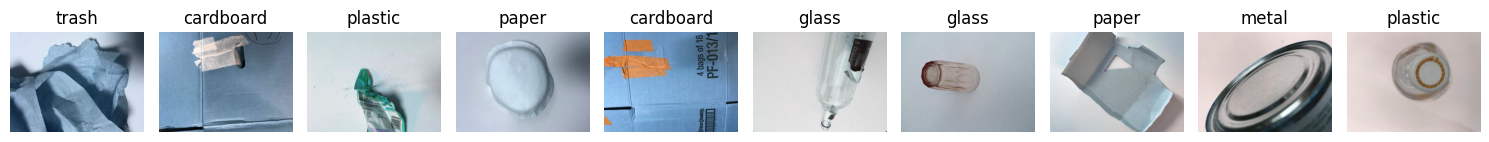

In [ ]:
def plot_images_from_df(df, num_images=3):
    # Set up the matplotlib figure and axes
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    # Loop through the number of images you want to display
    for i in range(num_images):
        # Read the image from the path
        image_path = df.iloc[i]['imgPath']
        label = df.iloc[i]['label']

        # Load image using OpenCV and convert from BGR to RGB for matplotlib
        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Plot the image on the corresponding subplot
        axes[i].imshow(image_rgb)
        axes[i].set_title(label)  # Set the title as the label
        axes[i].axis('off')       # Hide axis for a cleaner look

    plt.tight_layout()
    plt.show()

# Call the function to plot images
plot_images_from_df(df, num_images=10)  # Specify the number of images to plot

In [8]:
df_gaussian_blur = df.copy()

In [9]:
# Function to apply Gaussian blur and update DataFrame with new image paths
def apply_gaussian_blur_to_paths(df, save_path):
    for idx, row in df.iterrows():
        # Read the original image
        image_path = row['imgPath']
        # image = cv2.imread(image_path)

        # Apply Gaussian Blur
        # blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

        # Save the blurred image to a new file
        filename = os.path.basename(image_path)
        blurred_image_path = os.path.join(save_path, f"blurred_{filename}")
        # cv2.imwrite(blurred_image_path, blurred_image)

        # Update the DataFrame with the new image path
        df.at[idx, 'imgPath'] = blurred_image_path
        
# Example: Update DataFrame with blurred images saved to a new folder
apply_gaussian_blur_to_paths(df_gaussian_blur, save_path='Gaussian_Blured')  # Replace with your save path
# apply_gaussian_blur_to_paths(df_gaussian_blur, save_path='/content/drive/MyDrive/Gaussian_Blured')  # Replace with your save path

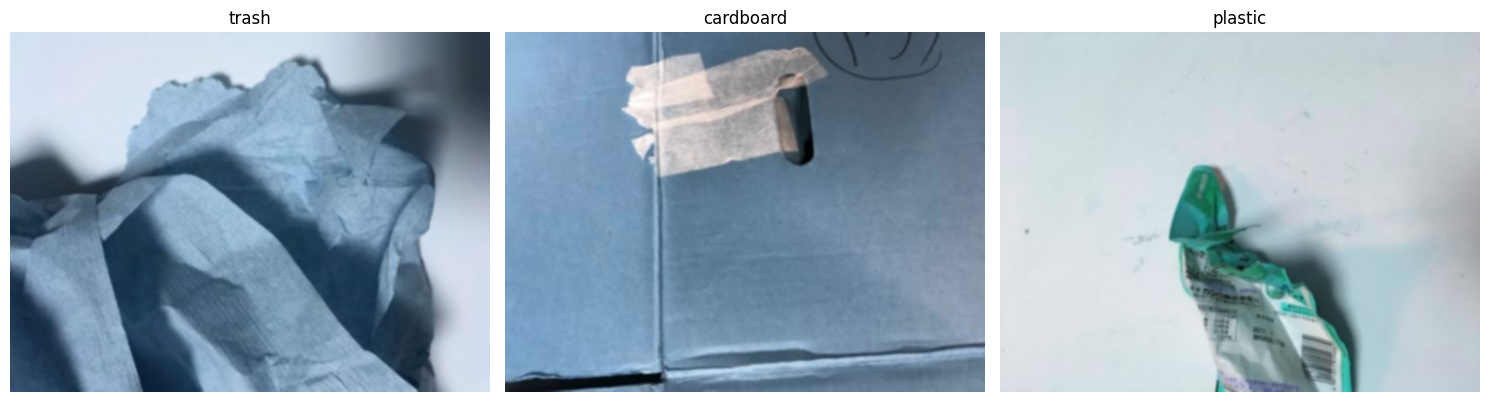

In [10]:
plot_images_from_df(df_gaussian_blur,3)

In [11]:
df_edges = df.copy()

In [12]:
# Function to apply Edge Detection and update DataFrame with new image paths
def apply_edge_detection_to_paths(df, save_path):
    for idx, row in df.iterrows():
        # Read the original image
        image_path = row['imgPath']
        # image = cv2.imread(image_path)

        # Apply Gaussian Blur
        # edges = cv2.Canny(image, 100, 200)

        # Save the blurred image to a new file
        filename = os.path.basename(image_path)
        edges_image_path = os.path.join(save_path, f"edges_{filename}")
        print(edges_image_path)
        # cv2.imwrite(edges_image_path, edges)

        # Update the DataFrame with the new image path
        df.at[idx, 'imgPath'] = edges_image_path

# Example: Update DataFrame with blurred images saved to a new folder
apply_edge_detection_to_paths(df_edges, save_path='edges')  # Replace with your save path
# apply_edge_detection_to_paths(df_edges, save_path='/content/drive/MyDrive/edges')  # Replace with your save path

edges\edges_trash17.jpg
edges\edges_cardboard356.jpg
edges\edges_plastic463.jpg
edges\edges_paper243.jpg
edges\edges_cardboard71.jpg
edges\edges_glass275.jpg
edges\edges_glass194.jpg
edges\edges_paper80.jpg
edges\edges_metal83.jpg
edges\edges_plastic31.jpg
edges\edges_trash118.jpg
edges\edges_cardboard105.jpg
edges\edges_paper512.jpg
edges\edges_paper282.jpg
edges\edges_trash19.jpg
edges\edges_glass342.jpg
edges\edges_paper233.jpg
edges\edges_metal43.jpg
edges\edges_paper491.jpg
edges\edges_metal200.jpg
edges\edges_cardboard60.jpg
edges\edges_plastic120.jpg
edges\edges_paper42.jpg
edges\edges_plastic311.jpg
edges\edges_plastic210.jpg
edges\edges_metal101.jpg
edges\edges_trash113.jpg
edges\edges_paper379.jpg
edges\edges_metal263.jpg
edges\edges_paper475.jpg
edges\edges_plastic236.jpg
edges\edges_paper206.jpg
edges\edges_cardboard281.jpg
edges\edges_cardboard178.jpg
edges\edges_glass110.jpg
edges\edges_metal298.jpg
edges\edges_metal309.jpg
edges\edges_cardboard367.jpg
edges\edges_trash12

In [13]:
df_gaussian_blur

,imgPath,label
0,Gaussian_Blured\blurred_trash17.jpg,trash
1,Gaussian_Blured\blurred_cardboard356.jpg,cardboard
2,Gaussian_Blured\blurred_plastic463.jpg,plastic
3,Gaussian_Blured\blurred_paper243.jpg,paper
4,Gaussian_Blured\blurred_cardboard71.jpg,cardboard
...,...,...
2522,Gaussian_Blured\blurred_glass22.jpg,glass
2523,Gaussian_Blured\blurred_metal191.jpg,metal
2524,Gaussian_Blured\blurred_glass207.jpg,glass
2525,Gaussian_Blured\blurred_metal7.jpg,metal


In [14]:
df_edges

,imgPath,label
0,edges\edges_trash17.jpg,trash
1,edges\edges_cardboard356.jpg,cardboard
2,edges\edges_plastic463.jpg,plastic
3,edges\edges_paper243.jpg,paper
4,edges\edges_cardboard71.jpg,cardboard
...,...,...
2522,edges\edges_glass22.jpg,glass
2523,edges\edges_metal191.jpg,metal
2524,edges\edges_glass207.jpg,glass
2525,edges\edges_metal7.jpg,metal


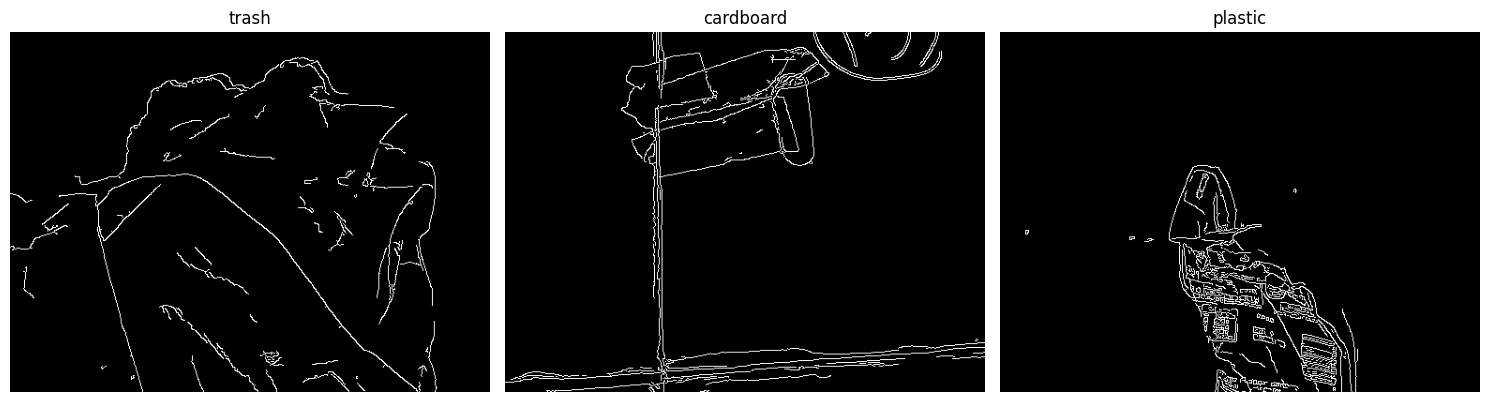

In [15]:
plot_images_from_df(df_edges,3)

In [16]:
# df.to_csv("Original.csv")
# df_gaussian_blur.to_csv("Gaussian.csv")
# df_edges.to_csv("Edges.csv")

In [3]:
df = pd.read_csv("Original.csv")
df_gaussian_blur = pd.read_csv("Gaussian.csv")
df_edges = pd.read_csv("Edges.csv")

In [9]:
import cv2
import pandas as pd

# Initialize the feature detector
sift = cv2.SIFT_create()
akaze = cv2.AKAZE_create()

# Define a function to apply on each image path
def compute_features_sift(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_image = cv2.equalizeHist(gray_image)
    if image is not None:
        keypoints, descriptors = sift.detectAndCompute(gray_image, None)
        descriptors = np.float32(descriptors)
        return keypoints, descriptors
    else:
        return None, None

# Apply the function to each image path in df_edges and store the result in two separate columns
df_edges["sift_keypoint"], df_edges["sift_descriptor"] = zip(*df_edges["imgPath"].apply(compute_features_sift))
df_gaussian_blur["sift_keypoint"], df_gaussian_blur["sift_descriptor"] = zip(*df_gaussian_blur["imgPath"].apply(compute_features_sift))

def compute_features_akaze(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray_image = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray_image = cv2.equalizeHist(gray_image)
    if image is not None:
        keypoints, descriptors = akaze.detectAndCompute(gray_image, None)
        descriptors = np.float32(descriptors)
        return keypoints, descriptors
    else:
        return None, None

df_edges["akaze_keypoint"], df_edges["akaze_descriptor"] = zip(*df_edges["imgPath"].apply(compute_features_akaze))
df_gaussian_blur["akaze_keypoint"], df_gaussian_blur["akaze_descriptor"] = zip(*df_gaussian_blur["imgPath"].apply(compute_features_akaze))



In [20]:
len(df_edges["sift_keypoint"][1])

205

In [10]:
df_gaussian_blur.to_csv("Gaussian.csv")
df_edges.to_csv("Edges.csv")

In [11]:
df_gaussian_blur.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527 entries, 0 to 2526
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        2527 non-null   int64 
 1   imgPath           2527 non-null   object
 2   label             2527 non-null   object
 3   sift_keypoint     2527 non-null   object
 4   sift_descriptor   2527 non-null   object
 5   akaze_keypoint    2527 non-null   object
 6   akaze_descriptor  2523 non-null   object
dtypes: int64(1), object(6)
memory usage: 138.3+ KB


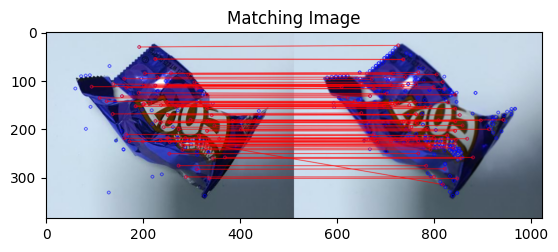

trash


In [22]:
# #create a system to find correspondences between several images( using keypoints matching) and apply it in recognition
# #use sift and akaze to find keypoints and descriptors
# #use flann to match the descriptors
# #use homography to find the transformation matrix
# #use warp perspective to apply the transformation matrix to the image
# #use the transformed image to train a model
# #use the model to predict the class of the image

# # Initialize the feature matcher
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm=1, trees=10)
search_params = dict(checks=100)
flann = cv2.FlannBasedMatcher(index_params, search_params)

# # Define a function to apply on each row of the DataFrame


def match_features(gaussian_blur, best_matches=0):
    target = cv2.imread('target/trash66.jpg')
    gray_target = cv2.cvtColor(target, cv2.COLOR_BGR2GRAY)
    gray_target = cv2.GaussianBlur(gray_target, (11,11), 0)
    gray_target = cv2.equalizeHist(gray_target, None)
    sift = cv2.SIFT_create()
    target_keypoint, target_descriptor = sift.detectAndCompute(gray_target, None)
    target_descriptor = np.float32(target_descriptor)
    # print(target_descriptor)
    # print(target_descriptor.shape)
    best_matches_data = None
    for index,row in gaussian_blur.iterrows():
        

        # Get the descriptors from the row
        sift_descriptor = row['sift_descriptor']
        # print(sift_descriptor)
        # print(sift_descriptor.shape)
        # print(type(sift_descriptor))
        akaze_descriptor = row['akaze_descriptor']
        # print(sift_descriptor)
        # print(akaze_descriptor)
        
        # If either of the descriptors is None, return None
        if sift_descriptor is None:
            continue
        if isinstance(sift_descriptor, np.float32):
            continue
        if sift_descriptor.shape[0] < 2:
            continue

        # Match the descriptors using FLANN
        matches = flann.knnMatch(target_descriptor, sift_descriptor, k=2)
        matchesMask = [[0,0] for _ in range(0, len(matches))]
        current_matches = 0
        for i, (fm, sm) in enumerate(matches):
            if fm.distance < 0.7 * sm.distance:
                matchesMask[i] = [1,0]
                current_matches += 1
        
        if best_matches < current_matches:
            best_matches = current_matches
            img = cv2.imread(row['imgPath'])
            best_matches_data = {
                'image_data' : img,
                'keypoint': row['sift_keypoint'],
                'descriptor' : row['sift_descriptor'],
                'match' : matches,
                'matchesmask' : matchesMask,
                'label' : row['label']
            }
    result = cv2.drawMatchesKnn(
        target,
        target_keypoint,
        best_matches_data['image_data'],
        best_matches_data['keypoint'],
        best_matches_data['match'],
        None,
        matchesMask = best_matches_data['matchesmask'],
        matchColor = [255, 0, 0],
        singlePointColor = [0,0,255]
    )
    plt.figure()
    plt.imshow(result)
    plt.title("Matching Image")
    plt.show()
    print(best_matches_data['label'])

    

# Apply the function to each row in the DataFrame
# df_edges['num_good_matches'] = df_edges.apply(match_features, axis=1)
match_features(df_gaussian_blur)


# df_edges.head()

# df_gaussian_blur.head()

# df_edges.to_csv("Edges_matching.csv")
# df_gaussian_blur.to_csv("Gaussian_matching.csv")



# COBA PAKE SVC

In [8]:
from sklearn.model_selection import train_test_split
from scipy.cluster.vq import *
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

X = df_gaussian_blur.drop(columns=['label','Unnamed: 0'])
y = df_gaussian_blur.label

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
label_mapping = {
    'metal': 1,
    'cardboard': 2,
    'glass': 3,
    'paper': 4,
    'plastic': 5,
    'trash': 6
}
y_train = y_train.map(label_mapping)
y_test = y_test.map(label_mapping)
stacked_descriptor = X_train['sift_descriptor'][0]
for descriptor in X_train['sift_descriptor'][1:]:
  stacked_descriptor = np.vstack((stacked_descriptor, descriptor))

stacked_descriptor = np.float32(stacked_descriptor)

centroids, _ = kmeans(stacked_descriptor, 15, 30)

image_features = np.zeros((len(X_train['imgPath']), len(centroids)), "float32")

for i, descriptor in enumerate(X_train['sift_descriptor']):
  words, _ = vq(descriptor, centroids)
  for w in words:
    image_features[i][w] += 1

std_scaler = StandardScaler().fit(image_features)
image_features = std_scaler.transform(image_features)

# Classifying and Training
svc = LinearSVC()
svc.fit(image_features, np.array(y_train))

test_feature = np.zeros((len(X_test['imgPath']), len(centroids)), "float32")

for i, descriptor in enumerate(X_test['sift_descriptor']):
  words, _ = vq(descriptor, centroids)
  for w in words:
    test_feature[i][w] += 1

std_scaler = StandardScaler().fit(test_feature)
test_feature = std_scaler.transform(test_feature)

result = svc.predict(test_feature)
accuracy = accuracy_score(y_test, result)
print(f"Accuracy: {accuracy}")
print("\nClassification Report:\n")
print(classification_report(y_test, result))

KeyboardInterrupt: 

In [23]:
# from sklearn.cluster import KMeans
# from scipy.cluster.vq import vq

# # Create a vocabulary of visual words using KMeans clustering
# def build_vocabulary(descriptors_list, num_clusters=100):
#     # print(descriptors_list)
#     # print(len(descriptors_list))
#     all_descriptors = descriptors_list[0]
#     for desc in descriptors_list[1:]:
#         if desc is None:
#             continue
#         if isinstance(desc, np.float32):
#             continue
#         if desc.shape[0] < 2:
#             continue
#         # print(len(desc))
#         if np.isnan(desc).any() or np.isinf(desc).any():
#             continue
#         all_descriptors = np.vstack((all_descriptors, desc))
#     kmeans = KMeans(n_clusters=num_clusters)
#     kmeans.fit(all_descriptors)
#     return kmeans

# # Convert descriptors into histograms using the vocabulary (BoW model)
# def compute_histograms(descriptors, kmeans):
#     num_clusters = len(kmeans.cluster_centers_)
    
#     if descriptors is None or descriptors.size == 0:
#         return np.zeros(num_clusters)  # Return a zero histogram
    
#     if np.isnan(descriptors).any() or np.isinf(descriptors).any():
#         return np.zeros(num_clusters)  # Handle invalid descriptors

#     # Assign each descriptor to a cluster (visual word)
#     words, _ = vq(descriptors, kmeans.cluster_centers_)
    
#     # Create a histogram of visual words
#     histogram = np.zeros(num_clusters)
    
#     # Ensure histogram size matches number of clusters
#     for word in words:
#         histogram[word] += 1
    
#     return histogram

# # Load images and extract features
# def prepare_dataset(df, df_descriptors, detector='SIFT', num_clusters=100):
#     descriptors_list = [desc for desc in df_descriptors if desc is not None and desc.size > 0]
#     histograms = []
#     # Build the BoW model
#     kmeans = build_vocabulary(descriptors_list, num_clusters=num_clusters)
    
#     # Compute histograms for each image
#     for _, row in df.iterrows():
#         descriptors = row['sift_descriptor']
#         # print(type(descriptors))
#         if descriptors is not None and descriptors.size > 0:
#             histogram = compute_histograms(descriptors, kmeans)
#             histograms.append(histogram)
    
#     return np.array(histograms)

# # Example images list

# # PATH = 'archive/GarbageClassification/cardboard/'

# X = prepare_dataset(df_gaussian_blur, df_gaussian_blur['sift_descriptor'], detector='SIFT', num_clusters=100)

# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense
# from sklearn.model_selection import train_test_split


In [24]:
# # Assuming y contains the corresponding labels
# # print(len(df_gaussian_blur['label']))
# # print(len(X))
# y = []
# for label in df_gaussian_blur['label']:
#     if label == "cardboard": y.append(0)
#     if label == "glass": y.append(1)
#     if label == "metal": y.append(2)
#     if label == "paper": y.append(3)
#     if label == "plastic": y.append(4)
#     if label == "trash": y.append(5)

# y = np.array(y)
# # print(len(y))
# # Split into train and test sets
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Build a simple fully connected network
# model = Sequential([
#     Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
#     Dense(64, activation='relu'),
#     Dense(10, activation='softmax')  # Adjust output size for your classes
# ])

# # Compile the model
# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# # Train the model
# model.fit(X_train, y_train, epochs=10, batch_size=32)

# # Evaluate the model
# test_loss, test_acc = model.evaluate(X_test, y_test)
# print(f"Test accuracy: {test_acc}")

In [25]:
# version for camera image

import numpy as np
from sklearn.cluster import KMeans
from scipy.cluster.vq import vq
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import pickle  # For saving and loading the KMeans model

# Build vocabulary
def build_vocabulary(descriptors_list, num_clusters=100):
    all_descriptors = np.vstack([
        desc for desc in descriptors_list
        if desc is not None and desc.size > 0 and not (np.isnan(desc).any() or np.isinf(desc).any())
    ])
    print(f"Shape of all_descriptors: {all_descriptors.shape}")
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(all_descriptors)
    return kmeans

# Compute histograms
def compute_histograms(descriptors, kmeans):
    num_clusters = len(kmeans.cluster_centers_)
    if descriptors is None or descriptors.size == 0 or np.isnan(descriptors).any() or np.isinf(descriptors).any():
        return np.zeros(num_clusters)
    words, _ = vq(descriptors, kmeans.cluster_centers_)
    histogram = np.zeros(num_clusters)
    for word in words:
        histogram[word] += 1
    return histogram

# Prepare dataset
def prepare_dataset(df, df_descriptors, num_clusters=100):
    # Filter valid descriptors for building the vocabulary
    descriptors_list = [
        desc for desc in df_descriptors
        if desc is not None and desc.size > 0 and not (np.isnan(desc).any() or np.isinf(desc).any())
    ]
    
    # Build vocabulary using valid descriptors
    kmeans = build_vocabulary(descriptors_list, num_clusters=num_clusters)

    # Save the KMeans model
    with open('kmeans_model.pkl', 'wb') as file:
        pickle.dump(kmeans, file)
    print("KMeans model saved as 'kmeans_model.pkl'.")

    # Prepare histograms and track valid rows
    histograms = []
    valid_indices = []
    for i, (_, row) in enumerate(df.iterrows()):
        descriptors = row['sift_descriptor']
        if descriptors is not None and descriptors.size > 0 and not (np.isnan(descriptors).any() or np.isinf(descriptors).any()):
            histogram = compute_histograms(descriptors, kmeans)
            histograms.append(histogram)
            valid_indices.append(i)  # Track valid row indices
    
    return np.array(histograms), valid_indices

# Map labels to integers
label_mapping = {"cardboard": 0, "glass": 1, "metal": 2, "paper": 3, "plastic": 4, "trash": 5}
y = np.array([label_mapping[label] for label in df_gaussian_blur['label']])

# Prepare the dataset and filter labels using valid indices
X, valid_indices = prepare_dataset(df_gaussian_blur, df_gaussian_blur['sift_descriptor'], num_clusters=100)
y = y[valid_indices]  # Filter labels to match the valid rows in X

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')  # 6 classes
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test accuracy: {test_acc}")

# Save the model
model.save('garbage_classification_model.h5')
print("Neural network model saved as 'garbage_classification_model.h5'.")


Shape of all_descriptors: (840753, 128)
KMeans model saved as 'kmeans_model.pkl'.
Epoch 1/10


c:\Users\steve\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2833 - loss: 2.6406 - val_accuracy: 0.4094 - val_loss: 1.5292
Epoch 2/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4631 - loss: 1.3958 - val_accuracy: 0.4715 - val_loss: 1.4226
Epoch 3/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5805 - loss: 1.1626 - val_accuracy: 0.4640 - val_loss: 1.4421
Epoch 4/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5849 - loss: 1.1128 - val_accuracy: 0.4814 - val_loss: 1.3787
Epoch 5/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6105 - loss: 1.0265 - val_accuracy: 0.4764 - val_loss: 1.3874
Epoch 6/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6754 - loss: 0.9040 - val_accuracy: 0.4814 - val_loss: 1.4288
Epoch 7/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6839 - loss: 0.8632 - val_accuracy: 0.4938 - val_loss: 1.3193
Epoch 8/10
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7215 - loss: 0.8129 - val_accuracy: 0.4913 - val_loss: 1.3561
Epo

Test accuracy: 0.523809552192688
Neural network model saved as 'garbage_classification_model.h5'.


In [26]:
# # Step 1: Import Required Libraries
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
# from tensorflow.keras.optimizers import Adam
# from tensorflow.keras.callbacks import EarlyStopping

# # Step 2: Define the Model Architecture
# def build_model(input_shape, num_classes):
#     model = Sequential()

#     # First convolutional block
#     model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
#     model.add(MaxPooling2D((2, 2)))

#     # Second convolutional block
#     model.add(Conv2D(64, (3, 3), activation='relu'))
#     model.add(MaxPooling2D((2, 2)))

#     # Third convolutional block
#     model.add(Conv2D(128, (3, 3), activation='relu'))
#     model.add(MaxPooling2D((2, 2)))

#     # Flatten and fully connected layers
#     model.add(Flatten())
#     model.add(Dense(128, activation='relu'))
#     model.add(Dropout(0.5))
#     model.add(Dense(num_classes, activation='softmax'))

#     return model

# # Step 3: Define Input Shape and Number of Classes
# input_shape = (224, 224, 3)  # Assuming the images are resized to 224x224 with 3 color channels
# classes = df['label'].unique().tolist()  # Define 'classes' as the unique labels from your DataFrame
# num_classes = len(classes)               # Number of unique classes in your dataset

# # Step 4: Build and Compile the Model
# model = build_model(input_shape, num_classes)
# model.summary()

# model.compile(optimizer=Adam(learning_rate=0.001),
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# # Step 5: Train the Model
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# history = model.fit(
#     X_train, y_train,
#     epochs=30,
#     batch_size=32,
#     validation_data=(X_val, y_val),
#     callbacks=[early_stopping]
# )

# # Step 6: Evaluate the Model
# val_loss, val_accuracy = model.evaluate(X_val, y_val)
# print(f"Validation Loss: {val_loss}")
# print(f"Validation Accuracy: {val_accuracy}")

# # Step 7: Save the Model
# model.save('garbage_classification_model.h5')


In [27]:
# plt.figure(figsize=(12, 4))

# # Plot training & validation accuracy values
# plt.subplot(1, 2, 1)
# plt.plot(history.history['accuracy'], label='Train Accuracy')
# plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
# plt.title('Model Accuracy')
# plt.xlabel('Epoch')
# plt.ylabel('Accuracy')
# plt.legend()

# # Plot training & validation loss values
# plt.subplot(1, 2, 2)
# plt.plot(history.history['loss'], label='Train Loss')
# plt.plot(history.history['val_loss'], label='Validation Loss')
# plt.title('Model Loss')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.legend()

# plt.show()
